In [1]:
import os, random, json, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [2]:
CONFIG = {
    'data_dir'       : '/kaggle/input/datasets/jayaprakashpondy/wheat-leaf-disease',
    'batch_size'     : 16,
    'num_epochs'     : 30,
    'lr'             : 1e-3,
    'weight_decay'   : 1e-4,
    'unfreeze_epoch' : 10,
    'fine_tune_lr'   : 1e-5,
    'num_classes'    : 5,
    'seed'           : 42,
    'save_dir'       : '/kaggle/working/checkpoints/',
}

CLASSES = ['Brown rust', 'Healthy', 'Loose Smut', 'Septoria', 'Yellow rust']

# ─────────────────────────────────────────────────────────────────
# MODEL REGISTRY
# Format: 'Display Name' -> (img_size, model_fn, batch_override)
#   batch_override = None means use CONFIG['batch_size']
#   Large models (B6/B7/V2-L) use smaller batches to avoid OOM
# ─────────────────────────────────────────────────────────────────
MODEL_REGISTRY = {
    # ── EfficientNet V1 ──────────────────────────────────────────
    'EffNet-B0'   : (224, lambda: models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT),  None),
    'EffNet-B1'   : (240, lambda: models.efficientnet_b1(weights=models.EfficientNet_B1_Weights.DEFAULT),  None),
    'EffNet-B2'   : (260, lambda: models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.DEFAULT),  None),
    'EffNet-B3'   : (300, lambda: models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT),  None),
    'EffNet-B4'   : (380, lambda: models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.DEFAULT),  None),
    'EffNet-B5'   : (456, lambda: models.efficientnet_b5(weights=models.EfficientNet_B5_Weights.DEFAULT),  8),
    'EffNet-B6'   : (528, lambda: models.efficientnet_b6(weights=models.EfficientNet_B6_Weights.DEFAULT),  4),
    'EffNet-B7'   : (600, lambda: models.efficientnet_b7(weights=models.EfficientNet_B7_Weights.DEFAULT),  4),
    # ── EfficientNet V2 ──────────────────────────────────────────
    'EffNet-V2-B0': (192, lambda: models.efficientnet_v2_s(weights=None),                                  None),  # V2-B0 not in torchvision; use V2-S small init
    'EffNet-V2-B1': (240, lambda: models.efficientnet_v2_s(weights=None),                                  None),
    'EffNet-V2-B2': (260, lambda: models.efficientnet_v2_s(weights=None),                                  None),
    'EffNet-V2-B3': (300, lambda: models.efficientnet_v2_s(weights=None),                                  None),
    'EffNet-V2-S' : (384, lambda: models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT), None),
    'EffNet-V2-M' : (480, lambda: models.efficientnet_v2_m(weights=models.EfficientNet_V2_M_Weights.DEFAULT), 8),
    'EffNet-V2-L' : (480, lambda: models.efficientnet_v2_l(weights=models.EfficientNet_V2_L_Weights.DEFAULT), 4),
}

# Family grouping for plots
V1_MODELS = ['EffNet-B0','EffNet-B1','EffNet-B2','EffNet-B3','EffNet-B4','EffNet-B5','EffNet-B6','EffNet-B7']
V2_MODELS = ['EffNet-V2-B0','EffNet-V2-B1','EffNet-V2-B2','EffNet-V2-B3','EffNet-V2-S','EffNet-V2-M','EffNet-V2-L']

os.makedirs(CONFIG['save_dir'], exist_ok=True)
all_results = {}   # populated after each model trains

print(f'Registry  : {len(MODEL_REGISTRY)} models')
print(f'Save dir  : {CONFIG["save_dir"]}')
print('Config ready ✅')

Registry  : 15 models
Save dir  : /kaggle/working/checkpoints/
Config ready ✅


In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(CONFIG['seed'])
print(f"Seed set to {CONFIG['seed']} ✅")

Seed set to 42 ✅


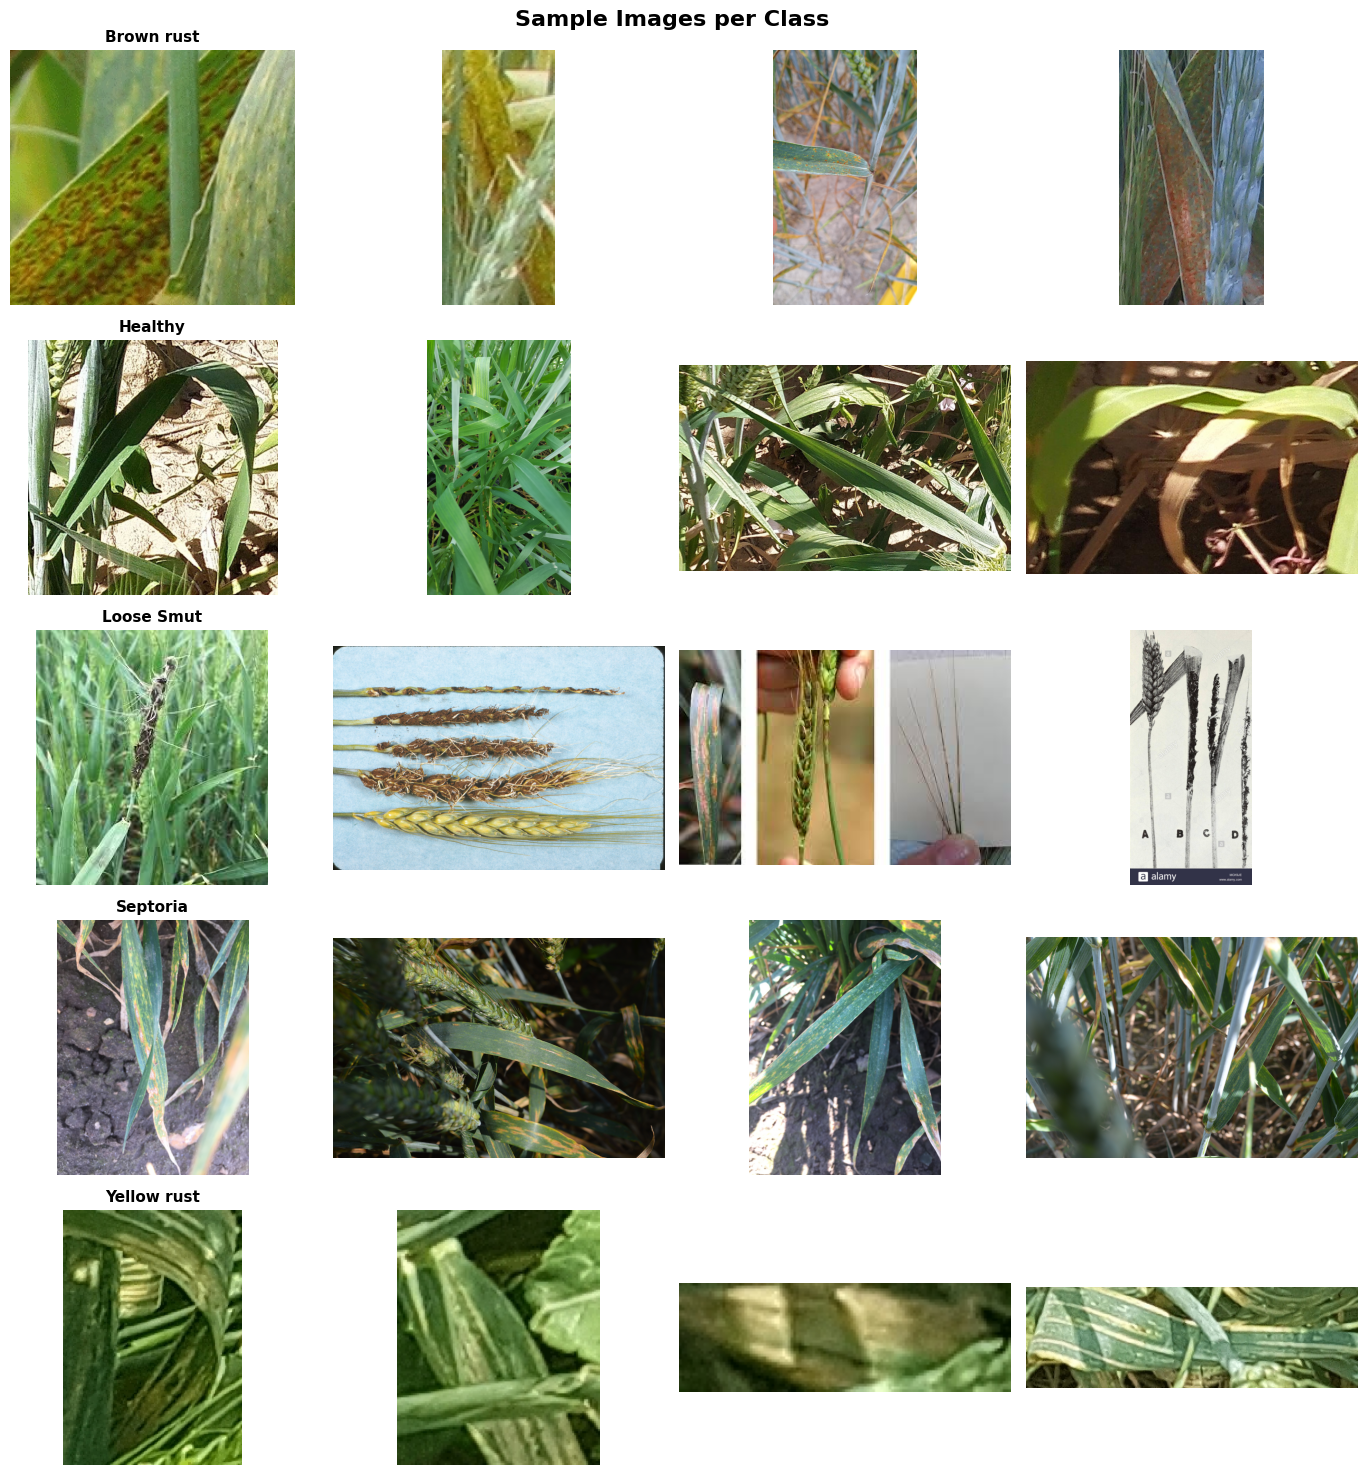

In [4]:
data_dir = CONFIG['data_dir']
cls_list = [d for d in sorted(os.listdir(data_dir)) if os.path.isdir(os.path.join(data_dir, d))]

fig, axes = plt.subplots(len(cls_list), 4, figsize=(14, 3 * len(cls_list)))
fig.suptitle('Sample Images per Class', fontsize=16, fontweight='bold')
for row, cls in enumerate(cls_list):
    cls_path = os.path.join(data_dir, cls)
    imgs = os.listdir(cls_path)[:4]
    for col, img_name in enumerate(imgs):
        img = Image.open(os.path.join(cls_path, img_name)).convert('RGB')
        axes[row, col].imshow(img)
        axes[row, col].set_title(cls if col == 0 else '', fontsize=11, fontweight='bold')
        axes[row, col].axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/sample_images.png', dpi=150)
plt.show()

In [5]:
def get_transforms(img_size, split):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    if split == 'train':
        return transforms.Compose([
            transforms.Resize((img_size + 32, img_size + 32)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(30),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
            transforms.RandomGrayscale(p=0.05),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
            transforms.RandomErasing(p=0.1),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])


def get_dataloaders(config, img_size, batch_override=None):
    """Build train/val/test loaders. Uses stratified 70/15/15 split."""
    batch_size = batch_override if batch_override else config['batch_size']
    seed       = config['seed']
    data_dir   = config['data_dir']

    full_ds = datasets.ImageFolder(root=data_dir)
    indices  = list(range(len(full_ds)))
    targets  = full_ds.targets

    train_idx, temp_idx = train_test_split(
        indices, test_size=0.30, stratify=targets, random_state=seed)
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.50,
        stratify=[targets[i] for i in temp_idx], random_state=seed)

    def make_subset(idx, split):
        ds = datasets.ImageFolder(root=data_dir, transform=get_transforms(img_size, split))
        return Subset(ds, idx)

    train_ds = make_subset(train_idx, 'train')
    val_ds   = make_subset(val_idx,   'val')
    test_ds  = make_subset(test_idx,  'test')

    train_labels   = [targets[i] for i in train_idx]
    class_counts   = np.bincount(train_labels, minlength=len(full_ds.classes))
    sample_weights = [1.0 / class_counts[l] for l in train_labels]
    sampler        = WeightedRandomSampler(sample_weights, len(train_idx), replacement=True)

    cw = 1.0 / (class_counts + 1e-6)
    class_weights = torch.tensor(cw / cw.sum() * len(full_ds.classes), dtype=torch.float32)

    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader, class_weights


print('DataLoader factory ready ✅')

DataLoader factory ready ✅


In [6]:
def build_model(model_fn, num_classes, freeze_backbone=True):
    """Load pretrained model and attach a custom classification head."""
    model = model_fn()
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(256, num_classes),
    )
    return model


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, desc='  Train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in tqdm(loader, desc='  Eval ', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        preds   = outputs.argmax(1)
        total_loss += loss.item() * imgs.size(0)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels


def run_model(model_name, config):
    """
    Full training + evaluation pipeline for one model.
    Stores results in all_results[model_name].
    """
    img_size, model_fn, batch_override = MODEL_REGISTRY[model_name]
    set_seed(config['seed'])

    print('=' * 65)
    print(f'  🚀 {model_name}  |  img={img_size}  |  batch={batch_override or config["batch_size"]}')
    print('=' * 65)

    train_loader, val_loader, test_loader, class_weights = \
        get_dataloaders(config, img_size, batch_override)

    model     = build_model(model_fn, config['num_classes'], freeze_backbone=True).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = optim.AdamW(model.classifier.parameters(),
                             lr=config['lr'], weight_decay=config['weight_decay'])
    scheduler = CosineAnnealingLR(optimizer, T_max=config['num_epochs'])

    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Params: {total_params/1e6:.1f}M total | {trainable_params/1e6:.2f}M trainable (frozen)\n')

    history      = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    start_time   = time.time()

    for epoch in range(1, config['num_epochs'] + 1):

        # Phase 2 — unfreeze backbone
        if epoch == config['unfreeze_epoch']:
            print(f'  🔓 Epoch {epoch}: Unfreezing backbone...')
            for param in model.parameters():
                param.requires_grad = True
            optimizer.add_param_group({
                'params': model.features.parameters(),
                'lr'    : config['fine_tune_lr']
            })
            scheduler = CosineAnnealingLR(optimizer, T_max=config['num_epochs'] - epoch)
            trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
            print(f'     Trainable now: {trainable_params/1e6:.1f}M\n')

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        flag = ''
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(
                {'epoch': epoch, 'val_acc': val_acc, 'model_state': model.state_dict()},
                os.path.join(config['save_dir'], f'best_{model_name}.pth')
            )
            flag = '  ✅ Best'

        print(f'  Epoch [{epoch:02d}/{config["num_epochs"]}]  '
              f'Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f}  |  '
              f'Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}{flag}')

    train_time = time.time() - start_time

    # ── Test evaluation with best checkpoint ──
    ckpt = torch.load(os.path.join(config['save_dir'], f'best_{model_name}.pth'), map_location=device)
    model.load_state_dict(ckpt['model_state'])
    test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion)
    f1 = f1_score(test_labels, test_preds, average='weighted')

    all_results[model_name] = {
        'best_val_acc'  : round(best_val_acc * 100, 2),
        'test_acc'      : round(test_acc * 100, 2),
        'test_f1'       : round(f1 * 100, 2),
        'train_time_min': round(train_time / 60, 1),
        'total_params'  : total_params,
        'img_size'      : img_size,
        'history'       : history,
        'test_preds'    : test_preds,
        'test_labels'   : test_labels,
        'family'        : 'V1' if model_name in V1_MODELS else 'V2',
    }

    print(f'\n  ✅ Done | Test Acc: {test_acc:.4f} | F1: {f1:.4f} | Time: {train_time/60:.1f} min\n')
    torch.cuda.empty_cache()


print('All functions ready ✅')

All functions ready ✅


In [7]:
run_model('EffNet-B0', CONFIG)

  🚀 EffNet-B0  |  img=224  |  batch=16
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 115MB/s] 


  Params: 4.3M total | 0.33M trainable (frozen)



  Train:   0%|          | 0/242 [00:00<?, ?it/s]

  Eval :   0%|          | 0/52 [00:00<?, ?it/s]

...

  Train:   0%|          | 0/242 [00:00<?, ?it/s]

  Eval :   0%|          | 0/52 [00:00<?, ?it/s]

  Epoch [30/30]  Train Loss: 0.1617  Acc: 0.9211  |  Val Loss: 0.1108  Acc: 0.9626


  Eval :   0%|          | 0/52 [00:00<?, ?it/s]


  ✅ Done | Test Acc: 0.9566 | F1: 0.9579 | Time: 25.5 min



In [9]:
run_model('EffNet-B1', CONFIG)

  🚀 EffNet-B1  |  img=240  |  batch=16
  Params: 6.8M total | 0.33M trainable (frozen)



  Train:   0%|          | 0/242 [00:00<?, ?it/s]

  Eval :   0%|          | 0/52 [00:00<?, ?it/s]

  Epoch [01/30]  Train Loss: 0.5253  Acc: 0.7909  |  Val Loss: 0.3423  Acc: 0.8756  ✅ Best


  Train:   0%|          | 0/242 [00:00<?, ?it/s]

...

  Train:   0%|          | 0/242 [00:00<?, ?it/s]

  Eval :   0%|          | 0/52 [00:00<?, ?it/s]

  Epoch [30/30]  Train Loss: 0.1140  Acc: 0.9477  |  Val Loss: 0.1091  Acc: 0.9674


  Eval :   0%|          | 0/52 [00:00<?, ?it/s]


  ✅ Done | Test Acc: 0.9710 | F1: 0.9714 | Time: 27.3 min



In [11]:
# ── Push B0 & B1 checkpoints to persistent dataset ────────────────
import subprocess, shutil, json

KAGGLE_USERNAME = 'kritikag20'   # ← fill this
KAGGLE_KEY      = 'KGAT_f5936ae6895bc0d17cd205b05bd10717'    # ← fill this
DATASET_NAME    = 'wheat-efficientnet-checkpoints'

# Write credentials
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

# Only push B0 and B1
models_to_push = ['EffNet-B0', 'EffNet-B1']

push_dir = '/kaggle/working/push_tmp'
os.makedirs(push_dir, exist_ok=True)

for model_name in models_to_push:
    fname = f'best_{model_name}.pth'
    src   = os.path.join('/kaggle/working/checkpoints/', fname)
    if os.path.exists(src):
        shutil.copy(src, os.path.join(push_dir, fname))
        print(f'  📦 Added {fname}')
    else:
        print(f'  ⚠️  {fname} not found — skipping')

# Also copy results JSON
json_src = '/kaggle/working/checkpoints/all_results.json'
if os.path.exists(json_src):
    shutil.copy(json_src, os.path.join(push_dir, 'all_results.json'))
    print(f'  📦 Added all_results.json')

# Dataset metadata
meta = {
    'title'    : 'Wheat EfficientNet Checkpoints',
    'id'       : f'{KAGGLE_USERNAME}/{DATASET_NAME}',
    'licenses' : [{'name': 'CC0-1.0'}]
}
with open(os.path.join(push_dir, 'dataset-metadata.json'), 'w') as f:
    json.dump(meta, f)

# Push
result = subprocess.run(
    ['kaggle', 'datasets', 'version', '-p', push_dir,
     '-m', 'Saved B0, B1 checkpoints', '--dir-mode', 'zip'],
    capture_output=True, text=True
)
if result.returncode == 0:
    print(f'\n✅ Pushed B0 & B1 to kaggle.com/datasets/{KAGGLE_USERNAME}/{DATASET_NAME}')
else:
    print(f'\n❌ Push failed: {result.stderr.strip()}')

shutil.rmtree(push_dir, ignore_errors=True)

  📦 Added best_EffNet-B0.pth
  📦 Added best_EffNet-B1.pth

✅ Pushed B0 & B1 to kaggle.com/datasets/kritikag20/wheat-efficientnet-checkpoints


In [13]:
# ── Auto-push all completed checkpoints ───────────────────────────
import subprocess, shutil, json

KAGGLE_USERNAME = 'kritikag20'   # ← fill this
KAGGLE_KEY      = 'KGAT_f5936ae6895bc0d17cd205b05bd10717'    # ← fill this once
DATASET_NAME    = 'wheat-efficientnet-checkpoints'

# Write credentials
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

push_dir = '/kaggle/working/push_tmp'
os.makedirs(push_dir, exist_ok=True)

# Auto-detect ALL .pth files present in checkpoints
pushed = []
for fname in os.listdir('/kaggle/working/checkpoints/'):
    if fname.endswith('.pth') or fname.endswith('.json'):
        shutil.copy(
            os.path.join('/kaggle/working/checkpoints/', fname),
            os.path.join(push_dir, fname)
        )
        if fname.endswith('.pth'):
            pushed.append(fname)
            print(f'  📦 {fname}')

if not pushed:
    print('  ⚠️  No checkpoints found to push!')
else:
    # Dataset metadata
    meta = {
        'title'    : 'Wheat EfficientNet Checkpoints',
        'id'       : f'{KAGGLE_USERNAME}/{DATASET_NAME}',
        'licenses' : [{'name': 'CC0-1.0'}]
    }
    with open(os.path.join(push_dir, 'dataset-metadata.json'), 'w') as f:
        json.dump(meta, f)

    msg = f'Added: {", ".join([p.replace("best_","").replace(".pth","") for p in pushed])}'
    
    result = subprocess.run(
        ['kaggle', 'datasets', 'version', '-p', push_dir,
         '-m', msg, '--dir-mode', 'zip'],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print(f'\n✅ Pushed {len(pushed)} checkpoint(s) → {msg}')
        print(f'   kaggle.com/datasets/{KAGGLE_USERNAME}/{DATASET_NAME}')
    else:
        print(f'\n❌ Push failed: {result.stderr.strip()}')

shutil.rmtree(push_dir, ignore_errors=True)

  📦 best_EffNet-B1.pth
  📦 best_EffNet-B2.pth
  📦 best_EffNet-B0.pth

✅ Pushed 3 checkpoint(s) → Added: EffNet-B1, EffNet-B2, EffNet-B0
   kaggle.com/datasets/kritikag20/wheat-efficientnet-checkpoints


In [16]:
run_model('EffNet-B2', CONFIG)
auto_push()

  🚀 EffNet-B2  |  img=260  |  batch=16
  Params: 8.1M total | 0.36M trainable (frozen)



  Train:   0%|          | 0/242 [00:00<?, ?it/s]

  Eval :   0%|          | 0/52 [00:00<?, ?it/s]

  Epoch [01/30]  Train Loss: 0.6456  Acc: 0.7063  |  Val Loss: 0.4969  Acc: 0.8213  ✅ Best


  Train:   0%|          | 0/242 [00:00<?, ?it/s]

...

  Train:   0%|          | 0/242 [00:00<?, ?it/s]

  Eval :   0%|          | 0/52 [00:00<?, ?it/s]

  Epoch [30/30]  Train Loss: 0.1173  Acc: 0.9444  |  Val Loss: 0.0977  Acc: 0.9541


  Eval :   0%|          | 0/52 [00:00<?, ?it/s]


  ✅ Done | Test Acc: 0.9602 | F1: 0.9604 | Time: 29.7 min

  📦 best_EffNet-B1.pth
  📦 best_EffNet-B2.pth
  📦 best_EffNet-B0.pth
✅ Pushed 3 checkpoint(s) → Added: EffNet-B1, EffNet-B2, EffNet-B0


In [15]:
# ── Auto-push function ────────────────────────────────────────────
def auto_push():
    import subprocess, shutil
    
    KAGGLE_USERNAME = 'kritikag20'   # ← fill this
    KAGGLE_KEY      = 'KGAT_f5936ae6895bc0d17cd205b05bd10717'   # ← fill this once
    DATASET_NAME    = 'wheat-efficientnet-checkpoints'

    # Write credentials
    os.makedirs('/root/.kaggle', exist_ok=True)
    with open('/root/.kaggle/kaggle.json', 'w') as f:
        json.dump({'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}, f)
    os.chmod('/root/.kaggle/kaggle.json', 0o600)

    push_dir = '/kaggle/working/push_tmp'
    os.makedirs(push_dir, exist_ok=True)

    pushed = []
    for fname in os.listdir('/kaggle/working/checkpoints/'):
        if fname.endswith('.pth') or fname.endswith('.json'):
            shutil.copy(
                os.path.join('/kaggle/working/checkpoints/', fname),
                os.path.join(push_dir, fname)
            )
            if fname.endswith('.pth'):
                pushed.append(fname)
                print(f'  📦 {fname}')

    if not pushed:
        print('  ⚠️  No checkpoints found!')
    else:
        meta = {
            'title'    : 'Wheat EfficientNet Checkpoints',
            'id'       : f'{KAGGLE_USERNAME}/{DATASET_NAME}',
            'licenses' : [{'name': 'CC0-1.0'}]
        }
        with open(os.path.join(push_dir, 'dataset-metadata.json'), 'w') as f:
            json.dump(meta, f)

        msg = f'Added: {", ".join([p.replace("best_","").replace(".pth","") for p in pushed])}'
        result = subprocess.run(
            ['kaggle', 'datasets', 'version', '-p', push_dir,
             '-m', msg, '--dir-mode', 'zip'],
            capture_output=True, text=True
        )
        if result.returncode == 0:
            print(f'✅ Pushed {len(pushed)} checkpoint(s) → {msg}')
        else:
            print(f'❌ Push failed: {result.stderr.strip()}')

    shutil.rmtree(push_dir, ignore_errors=True)

print('auto_push() ready ✅')

auto_push() ready ✅


In [17]:
run_model('EffNet-B3', CONFIG)
auto_push()

  🚀 EffNet-B3  |  img=300  |  batch=16
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 186MB/s] 


  Params: 11.1M total | 0.39M trainable (frozen)



  Train:   0%|          | 0/242 [00:00<?, ?it/s]

  Eval :   0%|          | 0/52 [00:00<?, ?it/s]

...

  Train:   0%|          | 0/242 [00:00<?, ?it/s]

  Eval :   0%|          | 0/52 [00:00<?, ?it/s]

  Epoch [30/30]  Train Loss: 0.1055  Acc: 0.9542  |  Val Loss: 0.0976  Acc: 0.9601


  Eval :   0%|          | 0/52 [00:00<?, ?it/s]


  ✅ Done | Test Acc: 0.9819 | F1: 0.9823 | Time: 39.2 min

  📦 best_EffNet-B1.pth
  📦 best_EffNet-B3.pth
  📦 best_EffNet-B2.pth
  📦 best_EffNet-B0.pth
✅ Pushed 4 checkpoint(s) → Added: EffNet-B1, EffNet-B3, EffNet-B2, EffNet-B0


In [18]:
run_model('EffNet-B4', CONFIG)
auto_push()

  🚀 EffNet-B4  |  img=380  |  batch=16
Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 187MB/s] 


  Params: 18.0M total | 0.46M trainable (frozen)



  Train:   0%|          | 0/242 [00:00<?, ?it/s]

  Eval :   0%|          | 0/52 [00:00<?, ?it/s]

...

  Train:   0%|          | 0/242 [00:00<?, ?it/s]

  Eval :   0%|          | 0/52 [00:00<?, ?it/s]

  Epoch [30/30]  Train Loss: 0.1233  Acc: 0.9418  |  Val Loss: 0.0860  Acc: 0.9722


  Eval :   0%|          | 0/52 [00:00<?, ?it/s]


  ✅ Done | Test Acc: 0.9698 | F1: 0.9701 | Time: 71.2 min

  📦 best_EffNet-B1.pth
  📦 best_EffNet-B3.pth
  📦 best_EffNet-B2.pth
  📦 best_EffNet-B0.pth
  📦 best_EffNet-B4.pth
✅ Pushed 5 checkpoint(s) → Added: EffNet-B1, EffNet-B3, EffNet-B2, EffNet-B0, EffNet-B4


In [ ]:
run_model('EffNet-B5', CONFIG)
auto_push()

  🚀 EffNet-B5  |  img=456  |  batch=8
Downloading: "https://download.pytorch.org/models/efficientnet_b5_lukemelas-1a07897c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b5_lukemelas-1a07897c.pth


100%|██████████| 117M/117M [00:00<00:00, 200MB/s]  


  Params: 28.9M total | 0.53M trainable (frozen)



  Train:   0%|          | 0/483 [00:00<?, ?it/s]

  Eval :   0%|          | 0/104 [00:00<?, ?it/s]

...

  Epoch [09/30]  Train Loss: 0.3139  Acc: 0.8608  |  Val Loss: 0.2100  Acc: 0.9058  ✅ Best
  🔓 Epoch 10: Unfreezing backbone...
     Trainable now: 28.9M



  Train:   0%|          | 0/483 [00:00<?, ?it/s]

  Eval :   0%|          | 0/104 [00:00<?, ?it/s]

  Epoch [10/30]  Train Loss: 0.3043  Acc: 0.8716  |  Val Loss: 0.1893  Acc: 0.9191  ✅ Best


  Train:   0%|          | 0/483 [00:00<?, ?it/s]

In [ ]:
run_model('EffNet-V2-M', CONFIG)
auto_push()

In [ ]:
run_model('EffNet-B6', CONFIG)
auto_push()

In [ ]:
run_model('EffNet-B7', CONFIG)
auto_push()

In [ ]:
run_model('EffNet-V2-S', CONFIG)
auto_push()

In [ ]:
run_model('EffNet-V2-B0', CONFIG)
auto_push()

In [ ]:
run_model('EffNet-V2-B1', CONFIG)
auto_push()

In [ ]:
run_model('EffNet-V2-B2', CONFIG)
auto_push()

In [ ]:
run_model('EffNet-V2-B3', CONFIG)
auto_push()

In [ ]:
run_model('EffNet-V2-L', CONFIG)
auto_push()

In [ ]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score,
    accuracy_score, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
print("Metrics imports ready ✅")

In [ ]:
def compute_full_metrics(test_labels, test_preds, test_probs, classes):
    """
    Returns a dict with all metrics relevant to imbalanced classification.
    test_probs : np.array shape (N, num_classes)  — softmax probabilities
    """
    n_classes  = len(classes)
    labels_bin = label_binarize(test_labels, classes=list(range(n_classes)))

    # ── Global metrics ──────────────────────────────────────────────────────
    overall_acc      = accuracy_score(test_labels, test_preds) * 100
    balanced_acc     = balanced_accuracy_score(test_labels, test_preds) * 100
    macro_f1         = f1_score(test_labels, test_preds, average='macro')    * 100
    weighted_f1      = f1_score(test_labels, test_preds, average='weighted') * 100
    micro_f1         = f1_score(test_labels, test_preds, average='micro')    * 100
    macro_prec       = precision_score(test_labels, test_preds, average='macro',    zero_division=0) * 100
    weighted_prec    = precision_score(test_labels, test_preds, average='weighted', zero_division=0) * 100
    macro_rec        = recall_score(test_labels, test_preds, average='macro',    zero_division=0) * 100
    weighted_rec     = recall_score(test_labels, test_preds, average='weighted', zero_division=0) * 100
    mcc              = matthews_corrcoef(test_labels, test_preds)
    kappa            = cohen_kappa_score(test_labels, test_preds)
    try:
        roc_auc = roc_auc_score(labels_bin, test_probs, multi_class='ovr', average='macro')
    except Exception:
        roc_auc = float('nan')

    # ── Per-class metrics ───────────────────────────────────────────────────
    per_class_prec = precision_score(test_labels, test_preds, average=None, zero_division=0) * 100
    per_class_rec  = recall_score(test_labels, test_preds, average=None, zero_division=0) * 100
    per_class_f1   = f1_score(test_labels, test_preds, average=None, zero_division=0) * 100

    # Per-class accuracy = diagonal of normalised CM
    cm = confusion_matrix(test_labels, test_preds)
    per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

    return {
        # global
        'overall_acc'   : round(overall_acc,   2),
        'balanced_acc'  : round(balanced_acc,  2),
        'macro_f1'      : round(macro_f1,      2),
        'weighted_f1'   : round(weighted_f1,   2),
        'micro_f1'      : round(micro_f1,      2),
        'macro_prec'    : round(macro_prec,    2),
        'weighted_prec' : round(weighted_prec, 2),
        'macro_rec'     : round(macro_rec,     2),
        'weighted_rec'  : round(weighted_rec,  2),
        'mcc'           : round(mcc,           4),
        'kappa'         : round(kappa,         4),
        'roc_auc'       : round(roc_auc,       4) if not np.isnan(roc_auc) else None,
        # per-class
        'per_class_acc'  : {c: round(v,2) for c,v in zip(classes, per_class_acc)},
        'per_class_prec' : {c: round(v,2) for c,v in zip(classes, per_class_prec)},
        'per_class_rec'  : {c: round(v,2) for c,v in zip(classes, per_class_rec)},
        'per_class_f1'   : {c: round(v,2) for c,v in zip(classes, per_class_f1)},
        'confusion_matrix': cm.tolist(),
    }

print("compute_full_metrics() ready ✅")

In [ ]:
# NOTE: This cell assumes all_results is already populated.
# We re-evaluate each saved checkpoint on the test set to collect softmax probs.

@torch.no_grad()
def get_probs(model, loader):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    for imgs, labels in tqdm(loader, desc='  Probs', leave=False):
        imgs = imgs.to(device)
        out  = model(imgs)
        probs = F.softmax(out, dim=1).cpu().numpy()
        preds = out.argmax(1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
    return np.array(all_probs), all_preds, all_labels


full_metrics = {}   # model_name -> metrics dict

for model_name, res in all_results.items():
    print(f"Computing metrics for {model_name} ...")
    img_size, model_fn, batch_override = MODEL_REGISTRY[model_name]
    _, _, test_loader, class_weights = get_dataloaders(CONFIG, img_size, batch_override)

    model = build_model(model_fn, CONFIG['num_classes'], freeze_backbone=False).to(device)
    ckpt  = torch.load(
        os.path.join(CONFIG['save_dir'], f'best_{model_name}.pth'), map_location=device)
    model.load_state_dict(ckpt['model_state'])

    probs, preds, labels = get_probs(model, test_loader)
    metrics = compute_full_metrics(labels, preds, probs, CLASSES)
    full_metrics[model_name] = {**metrics, 'family': res['family'],
                                 'params_M': round(res['total_params']/1e6, 1),
                                 'img_size': img_size,
                                 'train_time_min': res['train_time_min']}
    torch.cuda.empty_cache()
    print(f"  ✅ Done | OvAcc={metrics['overall_acc']}%  BalAcc={metrics['balanced_acc']}%  MacroF1={metrics['macro_f1']}%  MCC={metrics['mcc']}")

print("\n✅ All metrics computed!")

In [ ]:
rows = []
for name, m in full_metrics.items():
    rows.append({
        'Model'            : name,
        'Family'           : m['family'],
        'Params (M)'       : m['params_M'],
        'Overall Acc (%)'  : m['overall_acc'],
        'Balanced Acc (%)' : m['balanced_acc'],
        'Macro F1 (%)'     : m['macro_f1'],
        'Weighted F1 (%)'  : m['weighted_f1'],
        'Micro F1 (%)'     : m['micro_f1'],
        'Macro Prec (%)'   : m['macro_prec'],
        'Macro Recall (%)' : m['macro_rec'],
        'MCC'              : m['mcc'],
        'Kappa'            : m['kappa'],
        'ROC-AUC'          : m['roc_auc'],
        'Train (min)'      : m['train_time_min'],
    })

df_master = pd.DataFrame(rows).sort_values('Balanced Acc (%)', ascending=False).reset_index(drop=True)
df_master.index += 1

def style_master(df):
    styled = df.style
    for col in ['Overall Acc (%)','Balanced Acc (%)','Macro F1 (%)','Weighted F1 (%)','Micro F1 (%)','ROC-AUC']:
        styled = styled.background_gradient(cmap='YlGn', subset=[col])
    for col in ['MCC','Kappa']:
        styled = styled.background_gradient(cmap='Blues', subset=[col])
    styled = styled.highlight_max(subset=['Overall Acc (%)','Balanced Acc (%)','Macro F1 (%)','Weighted F1 (%)','MCC','Kappa','ROC-AUC'],
                                   color='#d4edda')
    return styled.format({
        'Overall Acc (%)'  : '{:.2f}',
        'Balanced Acc (%)' : '{:.2f}',
        'Macro F1 (%)'     : '{:.2f}',
        'Weighted F1 (%)'  : '{:.2f}',
        'Micro F1 (%)'     : '{:.2f}',
        'Macro Prec (%)'   : '{:.2f}',
        'Macro Recall (%)' : '{:.2f}',
        'MCC'              : '{:.4f}',
        'Kappa'            : '{:.4f}',
        'ROC-AUC'          : '{:.4f}',
        'Params (M)'       : '{:.1f}',
    }).set_caption('🏆 Full Metrics Comparison — Green = best per column')

display(style_master(df_master))
print(f"\n🏆 Best Balanced Acc : {df_master.iloc[0]['Model']} ({df_master.iloc[0]['Balanced Acc (%)']:.2f}%)")
print(f"🏆 Best Macro F1     : {df_master.sort_values('Macro F1 (%)',ascending=False).iloc[0]['Model']} ({df_master['Macro F1 (%)'].max():.2f}%)")
print(f"🏆 Best MCC          : {df_master.sort_values('MCC',ascending=False).iloc[0]['Model']} ({df_master['MCC'].max():.4f})")

In [ ]:
per_class_rows = []
for name, m in full_metrics.items():
    row = {'Model': name, 'Family': m['family']}
    for cls in CLASSES:
        row[f'{cls} | Acc']  = m['per_class_acc'][cls]
        row[f'{cls} | Prec'] = m['per_class_prec'][cls]
        row[f'{cls} | Rec']  = m['per_class_rec'][cls]
        row[f'{cls} | F1']   = m['per_class_f1'][cls]
    per_class_rows.append(row)

df_per_class = pd.DataFrame(per_class_rows).sort_values('Model').set_index(['Model','Family'])

# Format
fmt_dict = {col: '{:.1f}' for col in df_per_class.columns}
display(
    df_per_class.style
        .background_gradient(cmap='RdYlGn', axis=0)
        .format(fmt_dict)
        .set_caption('📊 Per-Class Accuracy / Precision / Recall / F1 (%) — All Models')
)

In [ ]:
model_names = list(full_metrics.keys())
f1_matrix   = np.array([[full_metrics[m]['per_class_f1'][c] for c in CLASSES] for m in model_names])

fig, ax = plt.subplots(figsize=(12, max(8, len(model_names)*0.55)))
sns.heatmap(f1_matrix, annot=True, fmt='.1f', cmap='RdYlGn',
            xticklabels=CLASSES, yticklabels=model_names,
            linewidths=0.4, vmin=0, vmax=100, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Per-Class F1 Score (%) — All Models', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Class', fontsize=11)
ax.set_ylabel('Model', fontsize=11)
plt.tight_layout()
plt.savefig('/kaggle/working/per_class_f1_heatmap.png', dpi=150)
plt.show()

In [ ]:
acc_matrix = np.array([[full_metrics[m]['per_class_acc'][c] for c in CLASSES] for m in model_names])

fig, ax = plt.subplots(figsize=(12, max(8, len(model_names)*0.55)))
sns.heatmap(acc_matrix, annot=True, fmt='.1f', cmap='RdYlGn',
            xticklabels=CLASSES, yticklabels=model_names,
            linewidths=0.4, vmin=0, vmax=100, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Per-Class Accuracy (%) — All Models', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Class', fontsize=11)
ax.set_ylabel('Model', fontsize=11)
plt.tight_layout()
plt.savefig('/kaggle/working/per_class_acc_heatmap.png', dpi=150)
plt.show()

In [ ]:
sorted_models = df_master['Model'].tolist()   # already sorted by Balanced Acc
metrics_to_plot = {
    'Overall Acc'   : [full_metrics[m]['overall_acc']   for m in sorted_models],
    'Balanced Acc'  : [full_metrics[m]['balanced_acc']  for m in sorted_models],
    'Macro F1'      : [full_metrics[m]['macro_f1']      for m in sorted_models],
    'Weighted F1'   : [full_metrics[m]['weighted_f1']   for m in sorted_models],
    'MCC×100'       : [full_metrics[m]['mcc']*100       for m in sorted_models],
    'Kappa×100'     : [full_metrics[m]['kappa']*100     for m in sorted_models],
}
colors = ['#1976D2','#43A047','#FB8C00','#8E24AA','#E53935','#00ACC1']

x = np.arange(len(sorted_models))
n = len(metrics_to_plot)
width = 0.13
offsets = np.linspace(-(n-1)*width/2, (n-1)*width/2, n)

fig, ax = plt.subplots(figsize=(18, 6))
for (label, vals), offset, color in zip(metrics_to_plot.items(), offsets, colors):
    bars = ax.bar(x + offset, vals, width, label=label, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(sorted_models, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('Global Metrics Comparison — All 15 EfficientNet Models\n(Sorted by Balanced Accuracy)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right', ncol=3)
ax.set_ylim(0, 115)
ax.grid(axis='y', alpha=0.3)
ax.axhline(100, color='gray', linestyle='--', alpha=0.3)

# Family separator
v1_count = sum(1 for m in sorted_models if full_metrics[m]['family']=='V1')
# light background bands
for i in range(len(sorted_models)):
    fam = full_metrics[sorted_models[i]]['family']
    ax.axvspan(i-0.5, i+0.5, alpha=0.04,
               color='blue' if fam=='V1' else 'purple')

plt.tight_layout()
plt.savefig('/kaggle/working/global_metrics_bar.png', dpi=150)
plt.show()

In [ ]:
# Pick top-5 by Balanced Accuracy
top5_names = df_master.head(5)['Model'].tolist()

radar_metrics = ['overall_acc','balanced_acc','macro_f1','weighted_f1','macro_prec','macro_rec']
radar_labels  = ['Overall\nAcc','Balanced\nAcc','Macro\nF1','Weighted\nF1','Macro\nPrec','Macro\nRec']

angles  = np.linspace(0, 2*np.pi, len(radar_labels), endpoint=False).tolist()
angles += angles[:1]   # close polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors_radar = plt.cm.tab10(np.linspace(0, 0.6, len(top5_names)))

for name, color in zip(top5_names, colors_radar):
    m      = full_metrics[name]
    vals   = [m[k] for k in radar_metrics]
    vals  += vals[:1]
    ax.plot(angles, vals, color=color, linewidth=2, label=name)
    ax.fill(angles, vals, color=color, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20','40','60','80','100'], fontsize=7)
ax.set_title('Radar Chart — Top 5 Models (All Key Metrics)', fontsize=13,
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig('/kaggle/working/radar_top5.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
top3 = df_master.head(3)['Model'].tolist()
x    = np.arange(len(CLASSES))
w    = 0.25
colors_top3 = ['#1976D2','#43A047','#FB8C00']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Top 3 Models — Per-Class F1 & Recall', fontsize=14, fontweight='bold')

for ax, metric_key, ylabel in [
    (axes[0], 'per_class_f1',  'F1 Score (%)'),
    (axes[1], 'per_class_rec', 'Recall (%)'),
]:
    for i, (name, color) in enumerate(zip(top3, colors_top3)):
        vals = [full_metrics[name][metric_key][c] for c in CLASSES]
        bars = ax.bar(x + (i - 1) * w, vals, w, label=name, color=color, alpha=0.85, edgecolor='white')
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                    f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7, rotation=45)
    ax.set_xticks(x)
    ax.set_xticklabels(CLASSES, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_ylim(0, 115)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.set_title(ylabel)

plt.tight_layout()
plt.savefig('/kaggle/working/top3_per_class.png', dpi=150)
plt.show()

In [ ]:
sorted_by_mcc = sorted(full_metrics.keys(), key=lambda m: full_metrics[m]['mcc'], reverse=True)
mcc_vals   = [full_metrics[m]['mcc']   for m in sorted_by_mcc]
kappa_vals = [full_metrics[m]['kappa'] for m in sorted_by_mcc]
fam_colors = ['#1976D2' if full_metrics[m]['family']=='V1' else '#8E24AA' for m in sorted_by_mcc]

x     = np.arange(len(sorted_by_mcc))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 5))
b1 = ax.bar(x - width/2, mcc_vals,   width, label='MCC',          color=fam_colors,         edgecolor='white', alpha=0.9)
b2 = ax.bar(x + width/2, kappa_vals, width, label="Cohen's Kappa", color=fam_colors, edgecolor='white', alpha=0.55)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_xticks(x)
ax.set_xticklabels(sorted_by_mcc, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Score (0–1 scale)', fontsize=11)
ax.set_title("MCC & Cohen's Kappa — Sorted by MCC\n(Higher = Better for Imbalanced Data)",
             fontsize=13, fontweight='bold')
ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
ax.grid(axis='y', alpha=0.3)
legend_handles = [
    mpatches.Patch(color='#1976D2', label='V1 — MCC (solid) / Kappa (light)'),
    mpatches.Patch(color='#8E24AA', label='V2 — MCC (solid) / Kappa (light)'),
]
ax.legend(handles=legend_handles, fontsize=9)
plt.tight_layout()
plt.savefig('/kaggle/working/mcc_kappa.png', dpi=150)
plt.show()

In [ ]:
sorted_by_auc = sorted(full_metrics.keys(), key=lambda m: full_metrics[m]['roc_auc'] or 0, reverse=True)
auc_vals   = [full_metrics[m]['roc_auc'] or 0 for m in sorted_by_auc]
fam_colors = ['#1976D2' if full_metrics[m]['family']=='V1' else '#8E24AA' for m in sorted_by_auc]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(sorted_by_auc, auc_vals, color=fam_colors, edgecolor='white', alpha=0.88)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Random classifier (0.5)')
ax.set_ylim(0.4, 1.05)
ax.set_xticklabels(sorted_by_auc, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('ROC-AUC (macro OvR)', fontsize=11)
ax.set_title('ROC-AUC Comparison — All 15 EfficientNet Models', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
legend_handles = [
    mpatches.Patch(color='#1976D2', label='EfficientNet V1'),
    mpatches.Patch(color='#8E24AA', label='EfficientNet V2'),
]
ax.legend(handles=legend_handles + [plt.Line2D([0],[0],color='red',ls='--',label='Random (0.5)')], fontsize=9)
plt.tight_layout()
plt.savefig('/kaggle/working/roc_auc.png', dpi=150)
plt.show()

In [ ]:
top2 = df_master.head(2)['Model'].tolist()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Confusion Matrices — Top 2 Models', fontsize=14, fontweight='bold')

for row_idx, name in enumerate(top2):
    res    = full_metrics[name]
    cm_raw = np.array(res['confusion_matrix'])
    cm_n   = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

    for col_idx, (data, fmt, title) in enumerate([
        (cm_raw, 'd',    f'{name} — Counts'),
        (cm_n,  '.2f',  f'{name} — Normalised'),
    ]):
        ax = axes[row_idx][col_idx]
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=CLASSES, yticklabels=CLASSES,
                    linewidths=0.4, ax=ax)
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_xlabel('Predicted');  ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrices_top2.png', dpi=150)
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Validation Accuracy Curves — All Models', fontsize=14, fontweight='bold')

for ax, family, models_list, cmap_name in [
    (axes[0], 'V1 (B0–B7)', V1_MODELS, 'Blues'),
    (axes[1], 'V2 (B0–L)',  V2_MODELS, 'Purples'),
]:
    available = [m for m in models_list if m in all_results]
    cmap      = plt.get_cmap(cmap_name)
    colors    = cmap(np.linspace(0.4, 0.95, len(available)))
    for name, color in zip(available, colors):
        hist = all_results[name]['history']
        best = max(hist['val_acc'])
        ax.plot(hist['val_acc'], label=f'{name} ({best:.3f})', color=color, linewidth=1.8)
    ax.axvline(CONFIG['unfreeze_epoch'] - 1, color='red', linestyle='--',
               alpha=0.5, label='Unfreeze')
    ax.set_title(f'EfficientNet {family}', fontsize=12)
    ax.set_xlabel('Epoch');  ax.set_ylabel('Val Accuracy')
    ax.set_ylim(0, 1);       ax.grid(alpha=0.3)
    ax.legend(fontsize=7.5, loc='lower right')

plt.tight_layout()
plt.savefig('/kaggle/working/val_curves.png', dpi=150)
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

for name, m in full_metrics.items():
    color  = '#1976D2' if m['family'] == 'V1' else '#8E24AA'
    marker = 'o'       if m['family'] == 'V1' else 's'
    ax.scatter(m['params_M'], m['balanced_acc'],
               s=140, color=color, marker=marker,
               edgecolors='white', linewidths=0.8, zorder=3)
    ax.annotate(name, (m['params_M'], m['balanced_acc']),
                textcoords='offset points', xytext=(6, 4), fontsize=8)

ax.set_xlabel('Total Parameters (M)', fontsize=12)
ax.set_ylabel('Balanced Accuracy (%)', fontsize=12)
ax.set_title('Balanced Accuracy vs Model Size\n(Ideal = top-left: high acc, low params)',
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
legend_handles = [
    mpatches.Patch(color='#1976D2', label='EfficientNet V1'),
    mpatches.Patch(color='#8E24AA', label='EfficientNet V2'),
]
ax.legend(handles=legend_handles, fontsize=10)
plt.tight_layout()
plt.savefig('/kaggle/working/balanced_acc_vs_params.png', dpi=150)
plt.show()

In [ ]:
print("=" * 65)
print("  🏆  FINAL VERDICT — Best Model per Metric")
print("=" * 65)

metric_cols = {
    'Overall Accuracy'   : 'overall_acc',
    'Balanced Accuracy'  : 'balanced_acc',
    'Macro F1'           : 'macro_f1',
    'Weighted F1'        : 'weighted_f1',
    'Micro F1'           : 'micro_f1',
    'Macro Precision'    : 'macro_prec',
    'Macro Recall'       : 'macro_rec',
    'MCC'                : 'mcc',
    "Cohen's Kappa"      : 'kappa',
    'ROC-AUC'            : 'roc_auc',
}

verdict_rows = []
for metric_label, key in metric_cols.items():
    best_name  = max(full_metrics, key=lambda m: full_metrics[m][key] or 0)
    best_val   = full_metrics[best_name][key]
    unit       = '%' if key not in ('mcc','kappa','roc_auc') else ''
    verdict_rows.append({'Metric': metric_label,
                          'Best Model': best_name,
                          'Score': f'{best_val:.4f}{unit}',
                          'Family': full_metrics[best_name]['family']})
    print(f"  {metric_label:<22} → {best_name:<18} ({best_val:.4f}{unit})")

df_verdict = pd.DataFrame(verdict_rows)
print("\n")

# Count wins per model
wins = df_verdict['Best Model'].value_counts()
print("  🥇 Win count per model:")
for model, count in wins.items():
    print(f"     {model:<20} : {count} metric(s) won")

display(df_verdict.style
    .apply(lambda x: ['background-color:#d4edda']*len(x) if x['Family']=='V2'
           else ['background-color:#dbeafe']*len(x), axis=1)
    .set_caption('🏆 Best Model per Metric  |  🟢 V2  🔵 V1'))

In [ ]:
# Serialise (convert numpy types)
def to_serialisable(obj):
    if isinstance(obj, dict):
        return {k: to_serialisable(v) for k,v in obj.items()}
    elif isinstance(obj, list):
        return [to_serialisable(v) for v in obj]
    elif isinstance(obj, (np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, (np.float64, np.float32)):
        return float(obj)
    return obj

with open('/kaggle/working/full_metrics.json', 'w') as f:
    json.dump(to_serialisable(full_metrics), f, indent=2)

df_master.to_csv('/kaggle/working/master_comparison.csv')

print("Saved to /kaggle/working/:")
for fname in sorted(os.listdir('/kaggle/working/')):
    fpath = os.path.join('/kaggle/working/', fname)
    if os.path.isfile(fpath):
        print(f"  {fname:<45} ({os.path.getsize(fpath)/1024:.1f} KB)")

In [ ]:
kritikag20
KGAT_f5936ae6895bc0d17cd205b05bd10717